Global map - Mean bias 

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import xarray as xr
import xcdat as xc
import numpy as np
import os

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


=== MODEL, FILE: EC-Earth3 10 /pscratch/sd/j/jungchoi/DCPP/_metrics/EC-Earth3/tas.144x72.YR10.mon_clim1981-2010.em.nc


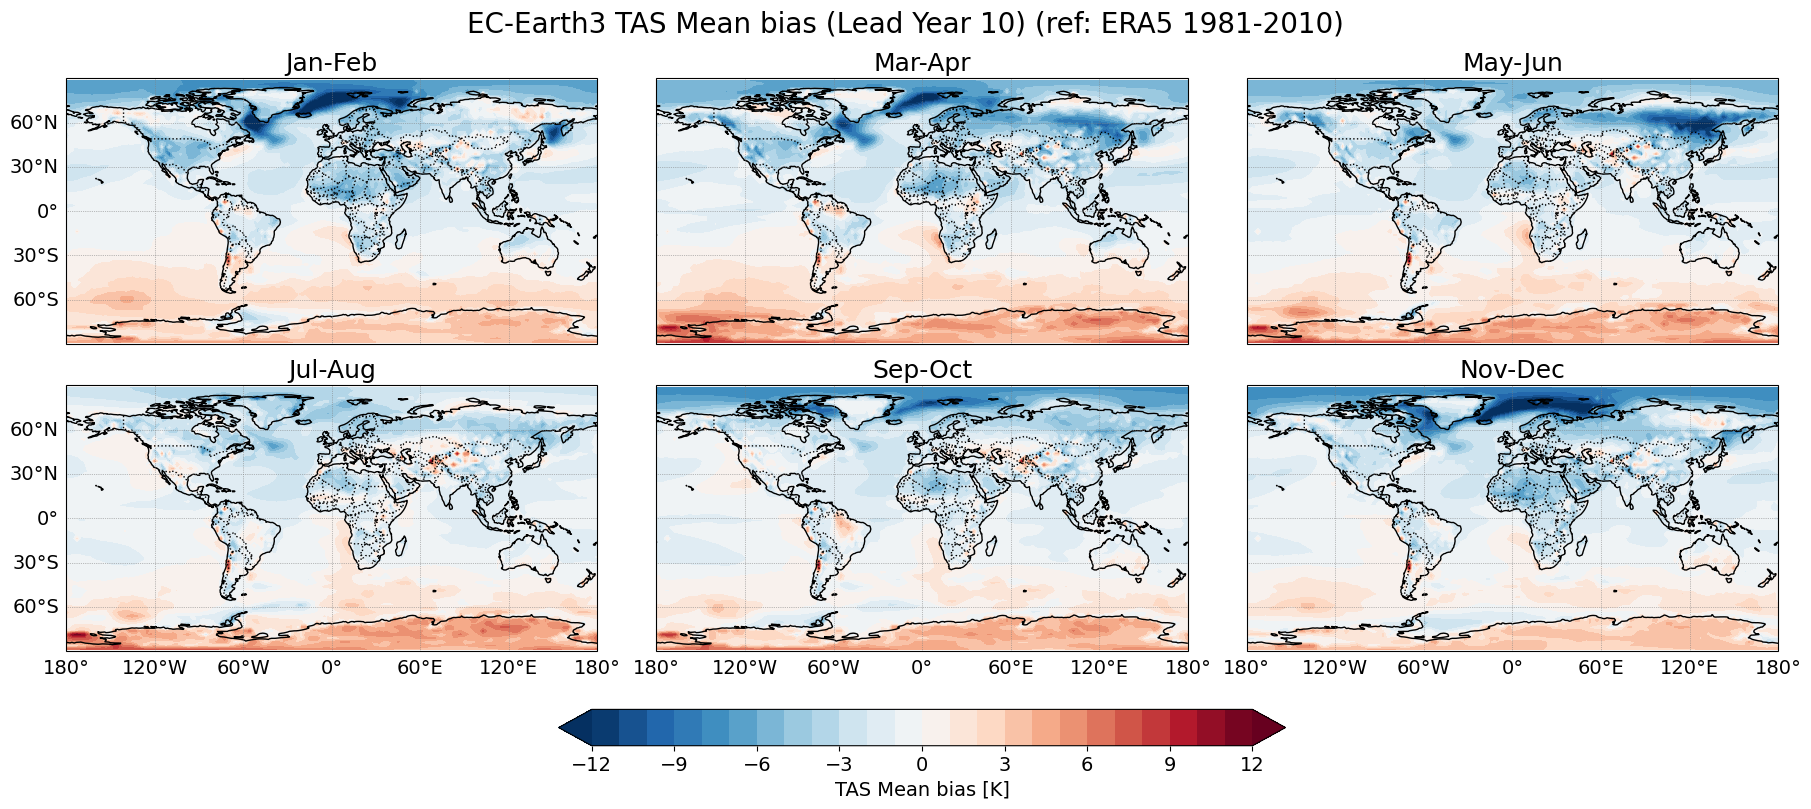

In [2]:
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MultipleLocator 

output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid_no = "144x72"

figout_dir = "/global/cfs/projectdirs/m4581/jungchoi/PMP/GMD2026/Fig1/_subplots"

var_name = "tas"
#var_name = "pr"

#model_list =  ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']
#lead_yr_list = ['HIST', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
## For FIg. 3
model_list =  ['EC-Earth3']
lead_yr_list = ['10']


for model in model_list:
    
    end_lead = len(lead_yr_list) + 1
    if model in ['CNRM-ESM2-1', 'MRI-ESM2-0']:
        end_lead = 5 + 1

    #print('=================end_lead=', end_lead)
    for lead_yr in lead_yr_list[0:end_lead]:

        #Read observed climatology
        obs_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.mon_clim1981-2010.nc"   
        obs_ds = xr.open_dataset(obs_file)
        obs_ds.close()
        
        # Read model mean climatology
        if lead_yr == "HIST":
            mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.historical.mon_clim1981-2010.em.nc"    
            lead_title = "Historical"
            lead_out = "HIST"
        else:
            mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.YR{lead_yr}.mon_clim1981-2010.em.nc"  
            lead_title = f"Lead Year {lead_yr}"
            lead_out = f"LY{lead_yr}"
            
        print('=== MODEL, FILE:', model, lead_yr, mdl_file)
        mdl_ds = xr.open_dataset(mdl_file)
        mdl_ds.close()
        
        # Define bias and 2-month average
        bias = mdl_ds[f"{var_name}"] - obs_ds[f"{var_name}"]
        #print(bias)
        bimonthly_group = ((bias['month'] - 1) // 2) + 1
        bimonthly_means = bias.groupby(bimonthly_group).mean(dim='month')
        #print(bimonthly_means)
        
        lons = bimonthly_means.lon
        lats = bimonthly_means.lat
        lon2d, lat2d = np.meshgrid(lons, lats)
        
        from cartopy.util import add_cyclic_point
        data = bimonthly_means 
        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lons, axis=-1)
        lon2d_cyclic, lat2d_cyclic = np.meshgrid(lon_cyclic, lats)
        
        labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec']
        
        # Define figure options
        if var_name == "tas": 
            title = "TAS"
            unit = "K"
            ref = "ERA5"
            cmap = "RdBu_r"
            clevs = np.arange(-12, 13, 1)
            
        if var_name == "pr":
            title = "PR"
            unit = "mm$\cdot$d$^{-1}$"
            ref = "GPCP"
            cmap = "BrBG"
            clevs = np.arange(-6, 6.5, 0.5)
        
        fig, axs = plt.subplots(2, 3, figsize=(18, 8),
                                subplot_kw={'projection': ccrs.PlateCarree()},
                                constrained_layout=True)
        
        for i in range(6):
            row = i // 3
            col = i % 3
            ax = axs[row, col]
        
            ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS, linestyle=':')
        
            data_i = data.sel(month=i+1)
        
            cf = ax.contourf(lon2d_cyclic, lat2d_cyclic, data_cyclic[i],
                             levels=clevs, cmap=cmap, extend='both',
                             transform=ccrs.PlateCarree())
        
            ax.set_title(labels[i], fontsize=18)
        
            gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.5, color='gray')
            gl.top_labels = False
            gl.right_labels = False
            gl.bottom_labels = (row == 1)
            gl.left_labels = (col == 0)
            gl.xlocator = MultipleLocator(60)
            gl.ylocator = MultipleLocator(30)
            gl.xlabel_style = {'size': 14}
            gl.ylabel_style = {'size': 14}
        
        # Add colorbar
        cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', fraction=0.06, pad=0.05)
        cbar.set_label(f"{title} Mean bias [{unit}]", fontsize=14)
        cbar.ax.tick_params(labelsize=14)
        
        fig.suptitle(f"{model} {title} Mean bias ({lead_title}) (ref: {ref} 1981-2010)", fontsize=20)
        plt.savefig(f"{figout_dir}/Mean_bias.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        #plt.savefig(f"_figs/Mean_bias.{title}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        plt.savefig(f"_figs/Fig3.eps", dpi=300, bbox_inches='tight', transparent=False)
        plt.show()
